# MAMMAL Model Inference

Run inference with a finetuned MAMMAL model on **any CSV file** containing SMILES strings.

All dataset, dataloader and task logic lives in **`mammal_utils.py`** (same folder).

## Steps
0. Configuration — edit paths here
1. Preview input data
2. Load tokenizer
3. Load model
4. Build DataLoader
5. Run inference
6. Inspect predictions
7. Evaluate (if labels available)
8. Enrichment metrics (Precision@K / EF@K)
9. Top hits

## 0. Configuration

**Edit the paths below before running.**

In [ ]:
import os
import torch

# ── USER SETTINGS ──────────────────────────────────────────────────────────────

# Path to the finetuned Lightning checkpoint (.ckpt)
MODEL_PATH = "/proj/ligand_ai/models/PGK2_DEL_cdd_to_creative_mammal/last-v2.ckpt"

# Path to the inference CSV/TSV file
DATA_PATH  = "/proj/ligand_ai/datasets_manager/processed/splits/PGK2_DEL_cdd_to_creative/test.csv"

# Where to write the predictions CSV
OUTPUT_PATH = "/proj/ligand_ai/results/PGK2_DEL_cdd_to_creative/mammal_notebook_predictions.csv"

# Column names in the input CSV
SMILES_COLUMN = "smiles"
LABEL_COLUMN  = "label"   # set to None if the file has no labels

# Base MAMMAL tokenizer / model (HuggingFace hub id or local path)
BASE_MODEL_PATH = "ibm/biomed.omics.bl.sm.ma-ted-458m"

# Inference device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# DataLoader settings
BATCH_SIZE            = 128
DRUG_MAX_SEQ_LENGTH   = 300
ENCODER_INPUT_MAX_LEN = 320
LABELS_MAX_LEN        = 10
NUM_WORKERS           = 0

# ── VALIDATION ─────────────────────────────────────────────────────────────────
assert os.path.exists(MODEL_PATH), f"Model not found: {MODEL_PATH}"
assert os.path.exists(DATA_PATH),  f"Data not found:  {DATA_PATH}"
os.makedirs(os.path.dirname(OUTPUT_PATH) or ".", exist_ok=True)

print(f"Model : {MODEL_PATH}")
print(f"Data  : {DATA_PATH}")
print(f"Output: {OUTPUT_PATH}")
print(f"Device: {DEVICE}")

Model : /proj/ligand_ai/models/PGK2_DEL_cdd_to_creative_mammal/last-v2.ckpt
Data  : /proj/ligand_ai/datasets_manager/processed/splits/PGK2_DEL_cdd_to_creative/test.csv
Output: /proj/ligand_ai/results/PGK2_DEL_cdd_to_creative/mammal_notebook_predictions.csv
Device: cuda


## 1. Preview Input Data

In [ ]:
import pandas as pd

sep = "\t" if DATA_PATH.endswith(".tsv") else ","
input_df = pd.read_csv(DATA_PATH, sep=sep)

print(f"Shape  : {input_df.shape}")
print(f"Columns: {list(input_df.columns)}")

if LABEL_COLUMN and LABEL_COLUMN in input_df.columns:
    print(f"\nLabel distribution:")
    print(input_df[LABEL_COLUMN].value_counts().sort_index())

input_df.head()

Shape  : (14748, 2)
Columns: ['smiles', 'label']

Label distribution:
label
0    13280
1     1468
Name: count, dtype: int64


,smiles,label
0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0
1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0
2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0
3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0
4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1


## 2. Load Tokenizer

In [ ]:
import sys, os
from pathlib import Path

# Add the notebooks directory to sys.path so mammal_utils can be imported.
# Works whether the notebook is run from its own directory or from elsewhere.
_nb_dir = Path(globals().get('__vsc_ipynb_file__', '') or os.getcwd())
if _nb_dir.is_file():
    _nb_dir = _nb_dir.parent
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from mammal_utils import load_tokenizer

tokenizer_op = load_tokenizer(BASE_MODEL_PATH)
print("Tokenizer loaded.")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/u/ella/miniconda/envs/ligand-ai/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Tokenizer loaded.


## 3. Load Model

In [ ]:
from mammal_utils import load_model

model = load_model(MODEL_PATH, BASE_MODEL_PATH, device=DEVICE)
print(model)

Path doesn't exist. Will try to download from hf hub. pretrained_model_name_or_path='ibm/biomed.omics.bl.sm.ma-ted-458m'


Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

Attempting to load model from dir: pretrained_model_name_or_path='/u/ella/.cache/huggingface/hub/models--ibm--biomed.omics.bl.sm.ma-ted-458m/snapshots/6d319d8dcf97f8821635327fc8cda24670553daa'
Mammal(
  (t5_model): T5ForConditionalGeneration(
    (shared): Embedding(100001, 768)
    (encoder): T5Stack(
      (embed_tokens): Embedding(100001, 768)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=768, out_features=768, bias=False)
                (k): Linear(in_features=768, out_features=768, bias=False)
                (v): Linear(in_features=768, out_features=768, bias=False)
                (o): Linear(in_features=768, out_features=768, bias=False)
                (relative_attention_bias): Embedding(32, 12)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )


## 4. Build DataLoader

In [ ]:
from mammal_utils import build_dataloader

dataloader = build_dataloader(
    df=input_df,
    tokenizer_op=tokenizer_op,
    smiles_column=SMILES_COLUMN,
    label_column=LABEL_COLUMN,
    batch_size=BATCH_SIZE,
    drug_max_seq_length=DRUG_MAX_SEQ_LENGTH,
    encoder_input_max_seq_len=ENCODER_INPUT_MAX_LEN,
    labels_max_seq_len=LABELS_MAX_LEN,
    num_workers=NUM_WORKERS,
)

InferenceDataset: 14748 samples, has_labels=True
DataLoader ready: 14748 samples, 116 batches


## 5. Run Inference

In [ ]:
from mammal_utils import run_inference

predictions_df = run_inference(
    model=model,
    dataloader=dataloader,
    tokenizer_op=tokenizer_op,
    device=DEVICE,
)

predictions_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved {len(predictions_df)} predictions to: {OUTPUT_PATH}")

Inference:   0%|          | 0/116 [00:00<?, ?it/s]


Saved 14748 predictions to: /proj/ligand_ai/results/PGK2_DEL_cdd_to_creative/mammal_notebook_predictions.csv


## 6. Inspect Predictions

In [ ]:
print(f"Shape: {predictions_df.shape}")
print(f"\nPredicted label distribution:")
print(predictions_df["predicted_label"].value_counts().sort_index())
print(f"\nScore statistics:")
print(predictions_df["prediction_score"].describe())
predictions_df.head(10)

Shape: (14748, 7)

Predicted label distribution:
predicted_label
0    13462
1     1286
Name: count, dtype: int64

Score statistics:
count    1.474800e+04
mean     8.735213e-02
std      2.806227e-01
min      9.136210e-08
25%      3.696008e-07
50%      5.529329e-07
75%      1.327393e-06
max      9.999967e-01
Name: prediction_score, dtype: float64


,sample_id,smiles,true_label,predicted_label,prediction_score,raw_score_negative,raw_score_positive
0,0,CNC(=O)[C@@H]1CN(Cc2ccc(OCc3cccc(C(=O)NCc4cc(C...,0,0,1.143947e-06,0.999999,1.143947e-06
1,1,CNC(=O)[C@@H]1[C@H]2CC[C@H](C2)[C@@H]1n1c(C(C)...,0,0,2.283712e-06,0.999998,2.283712e-06
2,2,CNC(=O)CC1CCN(C(=O)C(Cc2ccc(C#CCOc3c(C(F)(F)F)...,0,0,9.135719e-07,0.999999,9.135719e-07
3,3,CNC(=O)[C@@H]1C[C@H]2CCN(Cc3ccc(OCc4ccc(C(=O)N...,0,0,2.026409e-06,0.999998,2.026409e-06
4,4,CNC(=O)C1CCN(C(=O)[C@H]2CN(C(=O)c3cnc4[nH]cnc4...,1,1,9.999827e-01,0.000017,9.999827e-01
5,5,CNC(=O)[C@H](c1ccc(COC)cc1)N1CCN(C(=O)C2CCN(C(...,0,0,3.249810e-07,1.000000,3.249810e-07
6,6,CNC(=O)c1ccc(-n2c(C3CCSC3)nc3cc(CNCCCc4c(C)n[n...,0,0,7.845437e-07,0.999999,7.845437e-07
7,7,Cc1nc2ccc(S(=O)(=O)N[C@H](CC(=O)N3CCC[C@@H]3CC...,0,0,9.921659e-06,0.999990,9.921659e-06
8,8,CNC(=O)[C@@H]1CCN(C(=O)C2CCN(C(=O)c3ccc(OCc4c(...,0,0,1.126889e-06,0.999999,1.126889e-06
9,9,CNC(=O)[C@@H](c1ccccc1)N1CCN(C(=O)C2CCN(C(=O)c...,0,0,4.176971e-07,1.000000,4.176971e-07


## 7. Evaluate (if labels available)

CLASSIFICATION METRICS
Accuracy  : 0.9759
Precision : 0.9323
Recall    : 0.8168
F1 Score  : 0.8707
ROC AUC   : 0.9550
PR AUC    : 0.8682


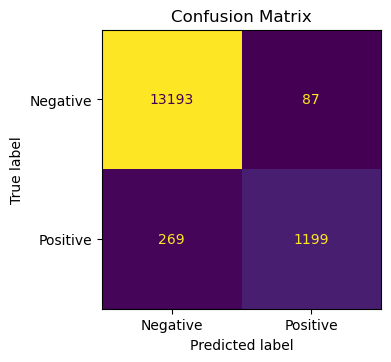

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

has_labels = predictions_df["true_label"].notna().any()

if has_labels:
    valid   = predictions_df[predictions_df["true_label"].notna()].copy()
    y_true  = valid["true_label"].astype(int)
    y_pred  = valid["predicted_label"].astype(int)
    y_score = valid["prediction_score"].astype(float)

    print("=" * 50)
    print("CLASSIFICATION METRICS")
    print("=" * 50)
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC AUC   : {roc_auc_score(y_true, y_score):.4f}")
    print(f"PR AUC    : {average_precision_score(y_true, y_score):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"]).plot(ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("No true labels found — skipping evaluation.")

## 8. Enrichment Metrics

Precision@K and Enrichment Factor (EF@K).

**EF@K** = Precision@K / hit_prevalence  
where hit_prevalence = fraction of positives in the full dataset.

In [ ]:
import numpy as np
from mammal_utils import calculate_enrichment_metrics

if has_labels:
    n_total = len(valid)
    top_k_values = sorted({k for k in [10, 50, 100, 500, 1000, 2000] if k <= n_total})
    if n_total not in top_k_values:
        top_k_values.append(n_total)

    enrichment = calculate_enrichment_metrics(
        y_true.values, y_score.values, top_k_values=top_k_values
    )

    n_positives = int(y_true.sum())
    hit_prev    = n_positives / n_total

    print("=" * 60)
    print("ENRICHMENT METRICS")
    print("=" * 60)
    print(f"Dataset : {n_total} compounds  |  Positives: {n_positives}  |  Hit rate: {hit_prev:.2%}")
    print()
    print(f"{'K':>8}  {'Precision@K':>12}  {'EF@K':>8}  {'Hits in top-K':>14}")
    print("-" * 50)
    for k in top_k_values:
        prec = enrichment.get(f"Precision@{k}", np.nan)
        ef   = enrichment.get(f"EF@{k}",        np.nan)
        hits = int(round(prec * k)) if not np.isnan(prec) else "N/A"
        print(f"{k:>8}  {prec:>12.4f}  {ef:>8.2f}  {hits:>14}")
    print("=" * 60)

    ef_rows = [
        {
            "K":             k,
            "Precision@K":   enrichment.get(f"Precision@{k}", np.nan),
            "EF@K":          enrichment.get(f"EF@{k}",        np.nan),
            "Hits_in_top_K": int(round(enrichment.get(f"Precision@{k}", 0) * k)),
        }
        for k in top_k_values
    ]
    ef_df = pd.DataFrame(ef_rows)
    ef_df
else:
    print("No true labels found — skipping enrichment metrics.")

ENRICHMENT METRICS
Dataset : 14748 compounds  |  Positives: 1468  |  Hit rate: 9.95%

       K   Precision@K      EF@K   Hits in top-K
--------------------------------------------------
      10        0.9000      9.04               9
      50        0.8800      8.84              44
     100        0.9400      9.44              94
     500        0.9780      9.83             489
    1000        0.9870      9.92             987
    2000        0.6235      6.26            1247
   14748        0.0995      1.00            1468


## 9. Top Hits

In [ ]:
top_hits = (
    predictions_df[predictions_df["predicted_label"] == 1]
    .sort_values("prediction_score", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

n_pos = (predictions_df["predicted_label"] == 1).sum()
print(f"Top 20 predicted positives (out of {n_pos} total predicted positives):")
top_hits[["sample_id", "smiles", "prediction_score", "true_label"]]

Top 20 predicted positives (out of 1286 total predicted positives):


,sample_id,smiles,prediction_score,true_label
0,5179,CNC(=O)CC1CCN(C(=O)[C@H](Cc2ccc(-c3cnc4[nH]c(O...,0.999997,0
1,1142,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)...,0.999996,1
2,8421,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)...,0.999996,1
3,6980,CNC(=O)CCNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)...,0.999995,1
4,13722,CNC(=O)C1CCC(NC(=O)c2cc(NCc3ccnc4[nH]ccc34)ccc...,0.999994,1
5,2127,CNC(=O)[C@H]1CN(C(=O)c2cnc3[nH]cnc3c2)C[C@@H]1...,0.999993,1
6,11791,CNC(=O)C1CCC(NC(=O)c2cc(NCc3ccncc3)ccc2Sc2ccc(...,0.999993,1
7,8871,CNC(=O)C1CCC(NC(=O)c2[nH]c3ccc(OC)cc3c2Cc2c(CN...,0.999993,1
8,9050,CNC(=O)CCNC(=O)C(Oc1ccc(Cc2c[nH]c3cc(Br)cc(NCc...,0.999993,1
9,14043,CNC(=O)CN1CCN(C(=O)c2ccc(F)c(Cc3c[nH]c4cc(Cl)c...,0.999992,1
